In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

True Sobol: [0.65789474 0.23684211 0.10526316]

Final Mirror: [0.6438557  0.24076537 0.11537893]
Polyak: [0.65307271 0.23515717 0.11177012]
True: [0.65789474 0.23684211 0.10526316]


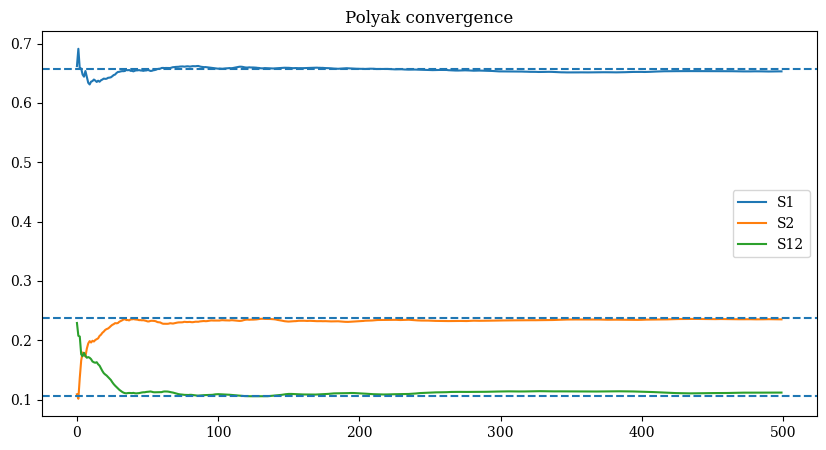

In [22]:
np.random.seed(0)

# =====================================================
# MODEL : Wiener chaos <= 2
# =====================================================

beta1 = 0.5
beta2 = 0.3
gamma = 0.2

def model(X):
    x1, x2 = X
    return beta1*x1 + beta2*x2 + gamma*x1*x2


Var = beta1**2 + beta2**2 + gamma**2

S_star = np.array([
    beta1**2,
    beta2**2,
    gamma**2
]) / Var

print("True Sobol:", S_star)

# =====================================================
# Möbius inverse matrix
# order = ({1}, {2}, {1,2})
# M^{-1}_{u,v} = 1_{v ⊂ u}
# =====================================================

M_inv = np.array([
    [1,0,0],
    [0,1,0],
    [1,1,1]
], dtype=float)


# =====================================================
# Gaussian sampling
# =====================================================

def sample_X():
    return np.random.randn(2)


# =====================================================
# Pick-Freeze
# =====================================================

def pick_freeze(subset, X, Xp):

    X_pf = X.copy()

    if subset == 0:        # freeze X1
        X_pf[1] = Xp[1]

    elif subset == 1:      # freeze X2
        X_pf[0] = Xp[0]

    # subset 2 -> full set -> Y(U)=Y

    return model(X_pf)


# =====================================================
# Mirror Descent
# =====================================================

def mirror_descent(n_iter=500000, eta0=10):

    S = np.ones(3)/3
    S_avg = np.zeros(3)

    m = 0.0

    subsets = [0,1,2]
    probs = np.ones(3)/3

    trajectory = []

    for t in range(1, n_iter+1):

        X = sample_X()
        Xp = sample_X()

        subset = np.random.choice(subsets, p=probs)

        Y = model(X)
        Y_pf = pick_freeze(subset, X, Xp)

        # running mean
        m += (Y - m)/(t)

        # TRUE matrix product !!!
        MS = M_inv @ S

        grad = (Y-m) * M_inv[subset] * (
            (Y-m)*MS[subset] - (Y_pf-m)
        )

        gamma_t = eta0/t **(0.501)

        # entropic mirror step
        S = S * np.exp(-gamma_t * grad)
        S /= S.sum()

        # Polyak average
        S_avg += (S - S_avg)/t

        if t % 1000 == 0:
            trajectory.append(S_avg.copy())

    return S, S_avg, np.array(trajectory)


# =====================================================
# RUN
# =====================================================

S_final, S_polyak, traj = mirror_descent()

print("\nFinal Mirror:", S_final)
print("Polyak:", S_polyak)
print("True:", S_star)


# =====================================================
# Convergence plot
# =====================================================

traj = np.array(traj)

plt.figure(figsize=(10,5))

labels = ["S1","S2","S12"]

for i in range(3):
    plt.plot(traj[:,i], label=labels[i])
    plt.axhline(S_star[i], linestyle='--')

plt.legend()
plt.title("Polyak convergence")
plt.show()

In [23]:
B = np.array([
    [1, -1, 0],
    [1, 1, -2]
], dtype=float)

# orthonormalisation
Q, _ = np.linalg.qr(B.T)  
P = Q.T      # matrice 2x3 de projection

Var = beta1**2 + beta2**2 + gamma**2

H = (Var/4) * np.array([
    [2,1,1],
    [1,2,1],
    [1,1,1]
])

H_T = P @ H @ P.T
H_T_inv = np.linalg.inv(H_T)

def sample_xi(n_samples=200000):

    xis = []

    m = 0  # car Y est centré théoriquement

    for _ in range(n_samples):

        X = sample_X()
        Xp = sample_X()

        subset = np.random.choice([0,1,2])

        Y = model(X)
        Y_pf = pick_freeze(subset, X, Xp)

        MS = M_inv @ S_star

        grad = (Y-m) * M_inv[subset] * (
            (Y-m)*MS[subset] - (Y_pf-m)
        )

        xis.append(grad)

    xis = np.array(xis)

    Sigma = np.cov(xis.T)

    return Sigma


Sigma = sample_xi()

Sigma_T = P @ Sigma @ P.T
V = H_T_inv @ Sigma_T @ H_T_inv

def run_many(n_runs=1000, n_iter=10000):

    Z = []

    for _ in range(n_runs):

        _, S_polyak, _ = mirror_descent(n_iter)

        err = np.sqrt(n_iter) * (S_polyak - S_star)

        Z.append(P @ err)

    return np.array(Z)


Z = run_many()

# diagonaliser V
eigvals, eigvecs = np.linalg.eigh(V)
V_half = eigvecs @ np.diag(np.sqrt(eigvals))

# blanchiment
Z_white = np.linalg.solve(V_half, Z.T).T



KeyboardInterrupt: 

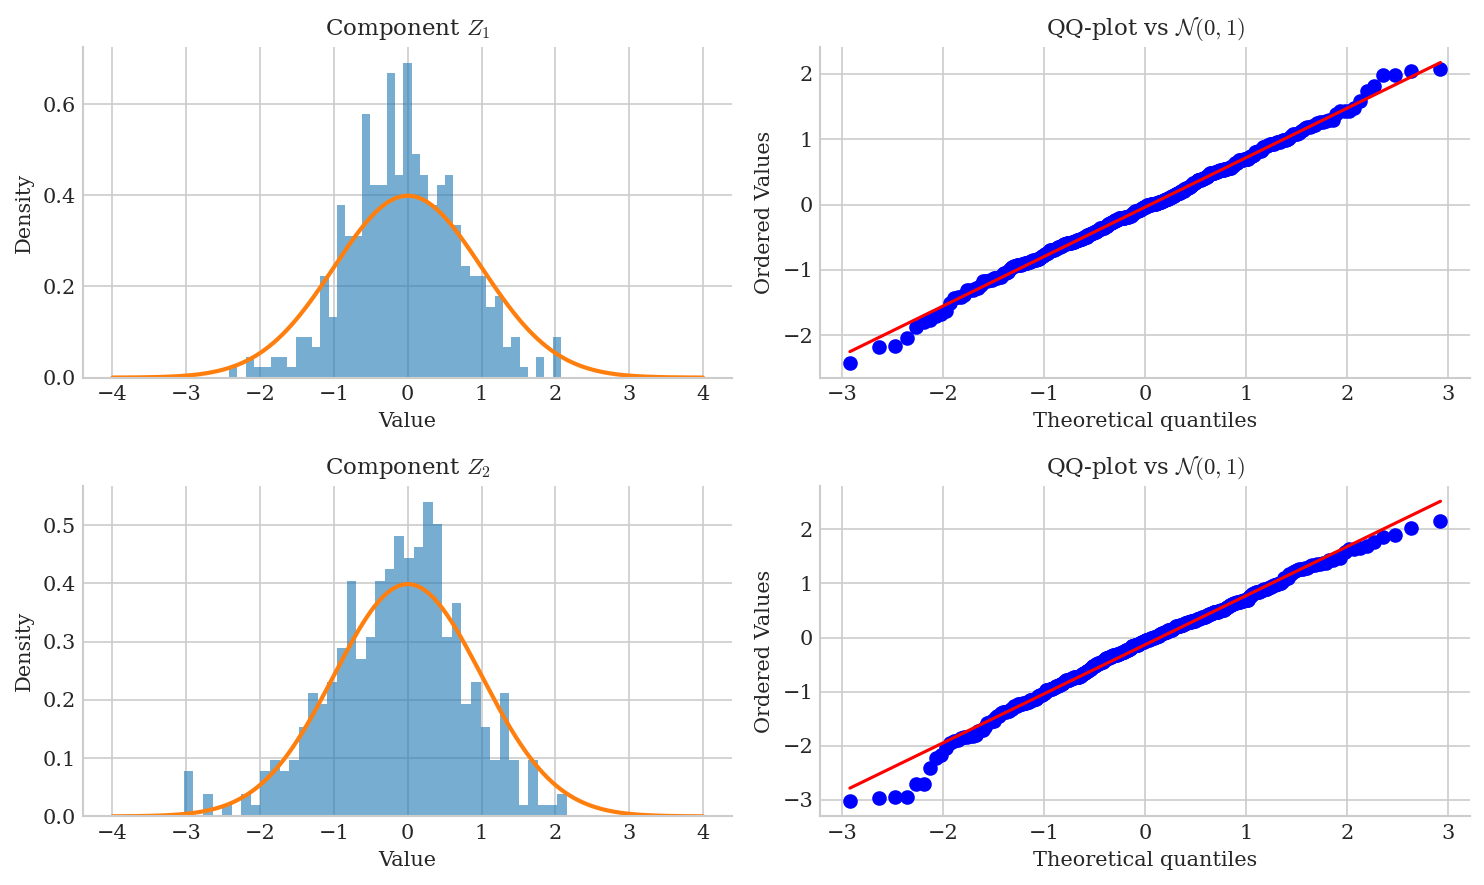

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10
})

fig, axes = plt.subplots(2, 2, figsize=(10,6), dpi=150)

x = np.linspace(-4, 4, 400)
gaussian_pdf = stats.norm.pdf(x, 0, 1)

for i in range(2):

    # -------- Histogramme --------
    ax_hist = axes[i, 0]

    ax_hist.hist(
        Z_white[:, i],
        bins=40,
        density=True,
        alpha=0.6
    )

    ax_hist.plot(
        x,
        gaussian_pdf,
        linewidth=2
    )

    ax_hist.set_title(rf"Component $s_{i+1}$", fontsize=11)
    ax_hist.set_xlabel("Value")
    ax_hist.set_ylabel("Density")

    # look minimaliste
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

    # -------- QQ Plot --------
    ax_qq = axes[i, 1]

    stats.probplot(
        Z_white[:, i],
        dist="norm",
        plot=ax_qq
    )

    ax_qq.set_title(rf"QQ-plot vs $\mathcal{{N}}(0,1)$", fontsize=11)

    ax_qq.spines['top'].set_visible(False)
    ax_qq.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("tcl_diagnostics.png", bbox_inches='tight')
plt.show()


In [24]:
def model(X):
    return beta1*X[:,0] + beta2*X[:,1] + gamma*X[:,0]*X[:,1]


def sample_X(size):
    return np.random.randn(size, 2)

def pick_freeze_vectorized(subset, X, Xp):

    X_new = X.copy()

    mask0 = subset == 0   # freeze X1 → replace X2
    mask1 = subset == 1   # freeze X2 → replace X1

    X_new[mask0, 1] = Xp[mask0, 1]
    X_new[mask1, 0] = Xp[mask1, 0]

    return model(X_new)



In [25]:
def mirror_descent_vectorized(n_runs=1000, n_iter=10000, eta0=10):

    # shape = (runs, dim)
    S = np.ones((n_runs, 3)) / 3
    S_avg = np.zeros_like(S)

    m = np.zeros(n_runs)

    subsets = np.arange(3)
    probs = np.ones(3)/3

    for t in range(1, n_iter+1):

        X = sample_X(size=n_runs)
        Xp = sample_X(size=n_runs)

        subset = np.random.choice(subsets, size=n_runs, p=probs)

        Y = model(X)
        Y_pf = pick_freeze_vectorized(subset, X, Xp)

        # running mean
        m += (Y - m)/t

        MS = S @ M_inv.T   # MUCH faster than looping

        grad = (
            (Y-m)[:,None]
            * M_inv[subset]
            * ((Y-m)[:,None] * MS[range(n_runs), subset][:,None]
               - (Y_pf-m)[:,None])
        )

        gamma_t = eta0 / t**0.501

        S *= np.exp(-gamma_t * grad)
        S /= S.sum(axis=1, keepdims=True)

        S_avg += (S - S_avg)/t

    return S_avg


In [28]:
def run_many_fast(n_runs=500, n_iter=100000):

    S_polyak = mirror_descent_vectorized(n_runs, n_iter)

    err = np.sqrt(n_iter) * (S_polyak - S_star)

    Z = err @ P.T

    return Z


In [29]:
Z = run_many_fast()

# diagonaliser V
eigvals, eigvecs = np.linalg.eigh(V)
V_half = eigvecs @ np.diag(np.sqrt(eigvals))

# blanchiment
Z_white = np.linalg.solve(V_half, Z.T).T

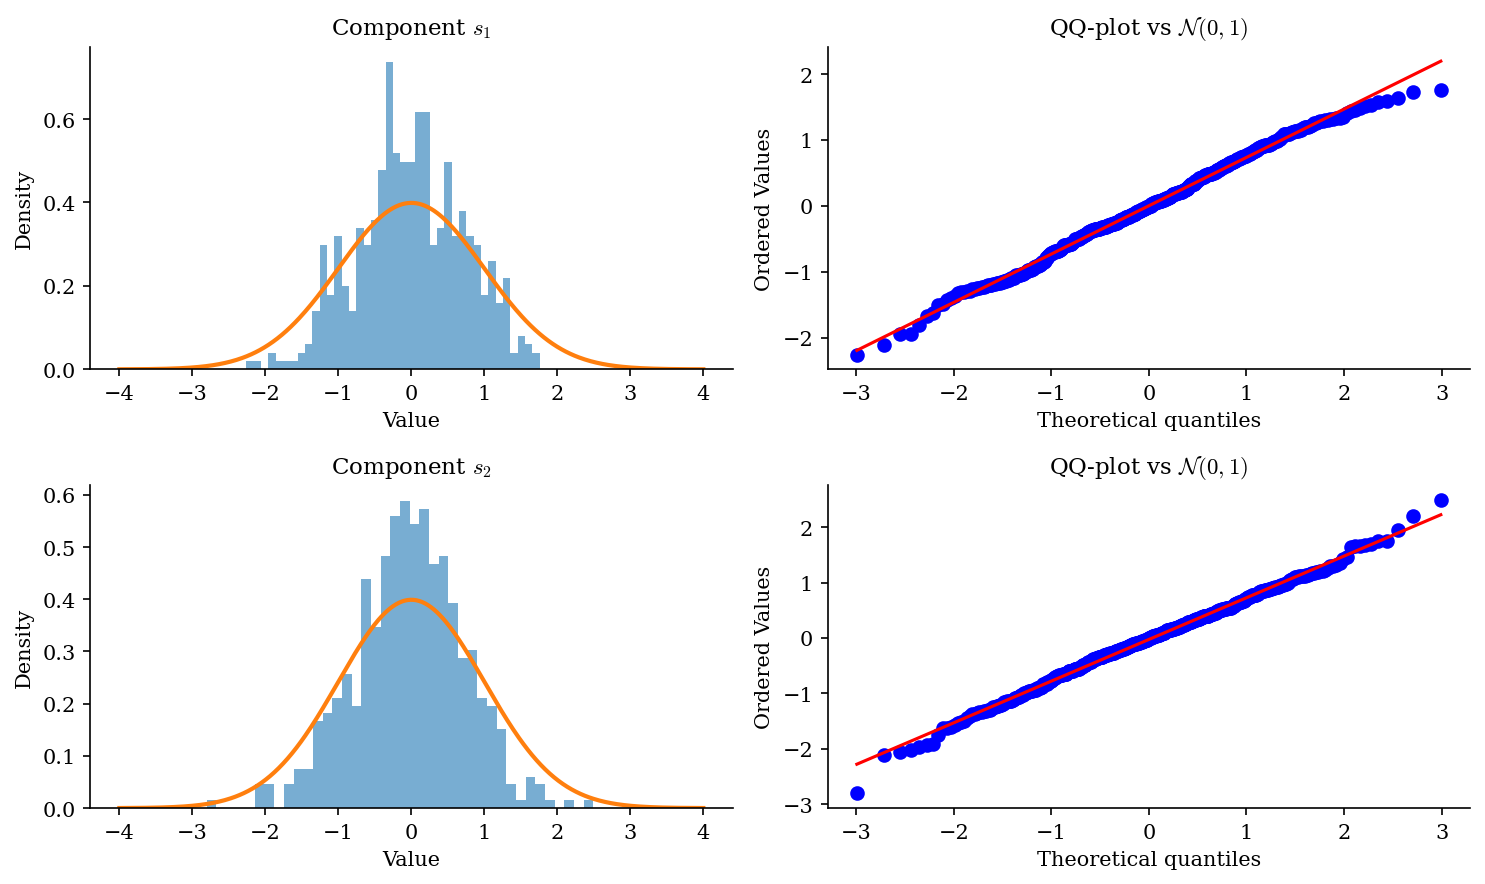

In [30]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10
})

fig, axes = plt.subplots(2, 2, figsize=(10,6), dpi=150)

x = np.linspace(-4, 4, 400)
gaussian_pdf = stats.norm.pdf(x, 0, 1)

for i in range(2):

    # -------- Histogramme --------
    ax_hist = axes[i, 0]

    ax_hist.hist(
        Z_white[:, i],
        bins=40,
        density=True,
        alpha=0.6
    )

    ax_hist.plot(
        x,
        gaussian_pdf,
        linewidth=2
    )

    ax_hist.set_title(rf"Component $s_{i+1}$", fontsize=11)
    ax_hist.set_xlabel("Value")
    ax_hist.set_ylabel("Density")

    # look minimaliste
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

    # -------- QQ Plot --------
    ax_qq = axes[i, 1]

    stats.probplot(
        Z_white[:, i],
        dist="norm",
        plot=ax_qq
    )

    ax_qq.set_title(rf"QQ-plot vs $\mathcal{{N}}(0,1)$", fontsize=11)

    ax_qq.spines['top'].set_visible(False)
    ax_qq.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("tcl_diagnostics.png", bbox_inches='tight')
plt.show()